# Importing libraries and display code from example

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets
from torch.utils.data import Subset
from torch.autograd import Variable
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# This function is used to display a batch of images.
def show_images(images) -> None:
    # Get the number of images in the batch.
    n: int = images.size(0)

    # Create a figure to display the images.
    f = plt.figure(figsize=(24, 6))
    # Loop through each image in the batch.
    for i in range(n):
        # Add a subplot for the current image.
        f.add_subplot(1, n, i + 1)
        # Display the image in grayscale.
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        # Turn off the axis labels.
        plt.axis('off')

    # Show the plot.
    plt.show(block=True)

# This function is used to display a batch of images along with their true labels and predicted labels.
def show_images_withPred(images,label,pred) -> None:
    # Get the number of images in the batch.
    n: int = images.size(0)

    # Create a figure to display the images.
    f = plt.figure(figsize=(24, 6))
    # Loop through each image in the batch.
    for i in range(n):
        # Add a subplot for the current image.
        f.add_subplot(1, n, i + 1)
        # Display the image in grayscale.
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        # Set the title to show the true label and the predicted label.
        plt.title("{} -> {}".format(label[i], pred[i]))
        #plt.title("Conf:{} \n {} -> {}".format(conf[i][pred[i]]*100,label[i], pred[i]))
        # Turn off the axis labels.
        plt.axis('off')

    # Show the plot.
    plt.show(block=True)

# Initializing MyEfficientNet from previous project and EarlyStop class

Implementing my model from the previous project, with 2 convolutional layers separated by a Batch Normilization layer and a Rectified Linear Unit layer, followed by a max pooling layer and three fully connected layers

In [2]:
class MyEfficientNet(nn.Module):
  def __init__(self):
    super(MyEfficientNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(1,-1)
    )
    self.fc1 = nn.LazyLinear(120)
    self.fc2 = nn.Linear(120, 80)
    self.fc3 = nn.Linear(80,10)

  def forward(self, x):
    out = self.features(x)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)

    return out

Initializing my early stop class

In [3]:
class EarlyStop:
  def __init__(self, patience=5, min_delta=0):
    self.patience = patience # Setting initial values
    self.min_delta = min_delta
    self.BestLoss = None
    self.stop = False
    self.counter = 0
    self.BestModel = None

  def __call__(self, val_loss, model):
    if self.BestLoss is None: #Checks if early stop has been used yet, if not sets initial values
      self.BestLoss = -val_loss
      self.BestModel = model.state_dict()

    elif -val_loss > self.BestLoss - self.min_delta: #Checks if loss has improved by at least min_delta amount
      self.counter += 1 # if not, counter is incremented
      if(self.counter >= self.patience): # if number of consecutive trainings has not resulted in improved model performance, training is stopped
        self.stop = True

    else: #if model performance has improved, we take note of new best loss value and save the current model state
      self.BestLoss = -val_loss
      self.BestModel = model.state_dict()
      self.counter = 0

  def load_best_model(self, model): # loads best model after stop
    model.load_state_dict(self.BestModel)


# Setting parameters and loading data

Setting parameters

In [4]:
lr = .001
batch_size = 250
num_epochs = 10
num_classes = 10
patience = 500
min_delta = 0

Loading the data

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()]) # transforming image to a Tensor

# Loading the dataset
train_dataset = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="data/", train=False, transform=transform)

# Putting the dataset into a DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=2, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 466kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]


# Training and testing the model on good data

Implementing the model

In [6]:
model = MyEfficientNet()
model.cuda()

MyEfficientNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): LazyLinear(in_features=0, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=80, bias=True)
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)

Initiating loss criterion, optimizer, and early stop function with patience set to 750 to prevent over/under fitting

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
earlystop = EarlyStop(patience=750, min_delta=0)

Training the model on the original images with early stopping implemented

In [8]:
model.train()
loss_list=[]
acc_list=[]
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()
    outputs = model(images)

    optimizer.zero_grad()

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    loss.backward()
    optimizer.step()

    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted==labels).sum().item()
    acc_list.append(correct/total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
    earlystop(loss, model)
    if earlystop.stop:
      print('Early Stopping')
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
      earlystop.load_best_model(model)
      break
  if earlystop.stop:
    break

Epoch [1/10], Step [0/240], Loss: 2.3166, Accuracy: 9.60%
Epoch [1/10], Step [150/240], Loss: 0.0980, Accuracy: 98.40%
Epoch [2/10], Step [0/240], Loss: 0.0969, Accuracy: 96.40%
Epoch [2/10], Step [150/240], Loss: 0.0506, Accuracy: 98.80%
Epoch [3/10], Step [0/240], Loss: 0.0260, Accuracy: 100.00%
Epoch [3/10], Step [150/240], Loss: 0.0474, Accuracy: 99.20%
Epoch [4/10], Step [0/240], Loss: 0.0077, Accuracy: 100.00%
Early Stopping
Epoch [4/10], Step [30/240], Loss: 0.0071, Accuracy: 100.00%


Evaluating model performance on the unaltered test images

In [9]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (images, labels) in enumerate(test_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Accuracy of the model on the 10000 test images: 98.63 %


# Initializing Fast Gradient Sign Method

Implementing the FGSM

In [10]:
def fgsm(model, criterion, images, labels, step_size):

  images.requires_grad = True
  outputs =  model(images)

  model.zero_grad()
  loss = criterion(outputs, labels)
  loss.backward() #Up until this point, fairly standard prediction code

  change_image_sign = images.grad.sign() #Obtaining gradient sign

  altered_images = images + step_size*change_image_sign #altering the images by the given step size based off the gradient sign
  altered_images = torch.clamp(altered_images, 0, 1)

  return altered_images

# FGSM implementation

Testing model performance against the FGSM images

In [11]:
model.eval()

correct_fgsm = 0
total_fgsm = 0

for images, labels in test_loader:
  images = images.cuda()
  labels = labels.cuda()

  altered_fgsm_images = fgsm(model, criterion, images, labels, step_size=.2)

  outputs = model(altered_fgsm_images)

  _, predicted = torch.max(outputs.data, 1)
  total_fgsm += labels.size(0)
  correct_fgsm += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the 10000 test images: {} %'.format((correct_fgsm / total_fgsm) * 100))


Accuracy of the model on the 10000 test images: 4.37 %


## Plotting FGSM results next to original images

As can be seen below, the noise from FGSM can be seen on the images

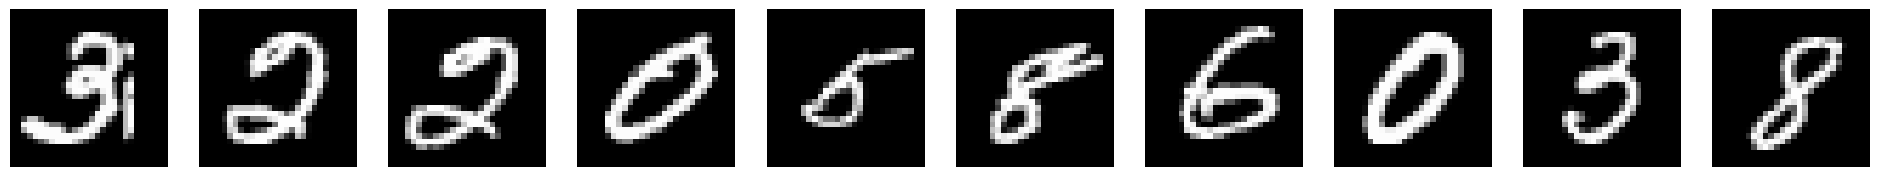

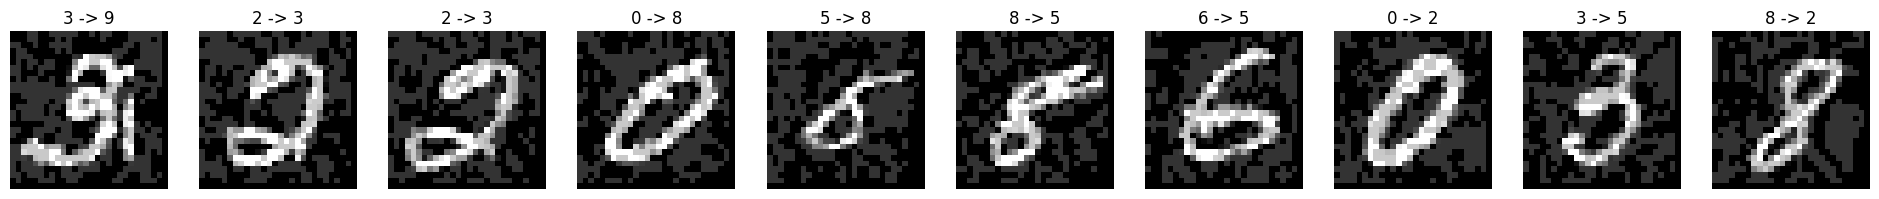

In [12]:
show_images(images[:10].detach().cpu())
show_images_withPred(altered_fgsm_images[:10].detach().cpu(),labels[:10].cpu(), outputs[:10].argmax(dim=1).cpu())

# Initializing Projected Gradient Descent

Defining PGD

In [13]:
def pgd(model, images, labels, criterion, epsilon, step_size, iters):

  original_images = images.data #Saving the original image data to combine with the altered values later

  for i in range(iters): #Altering the images iters times

    images.requires_grad = True
    outputs = model(images)

    model.zero_grad()
    loss = criterion(outputs, labels)

    loss.backward() # Up until this point, fairly standard prediction code

    adversarial_image = images + step_size*images.grad.sign() #Increasing the image by step size in direction of gradient's sign

    new_image = adversarial_image-original_images #Creating essentially a filter for the image

    new_image = torch.clamp(new_image, min=-epsilon, max=epsilon) #Ensuring the image filter does not exceed epsilon values

    images = torch.clamp(original_images + new_image, min=0, max=1).detach_() #Combining the original image with the doctored filter, then repeating

  return images

#PGD Implementation

Evaluating PGD performance

In [14]:
model.eval()

correct_pgd = 0
total_pgd = 0

for images, labels in test_loader:
  images = images.cuda()
  labels = labels.cuda()

  altered_pgd_images = pgd(model, images, labels, criterion, epsilon=.3, step_size=.2, iters=40)

  outputs = model(altered_pgd_images)

  _, predicted = torch.max(outputs.data, 1)
  total_pgd += labels.size(0)
  correct_pgd += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the 10000 test images: {} %'.format((correct_pgd / total_pgd) * 100))


Accuracy of the model on the 10000 test images: 0.0 %


## Plotting PGD results next to original images

Plotting normal images against PGD images. Clearly alterations can be seen on the PGD images

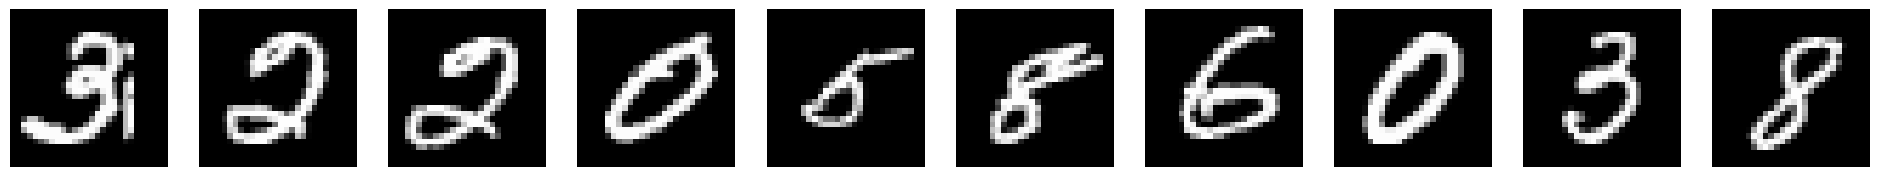

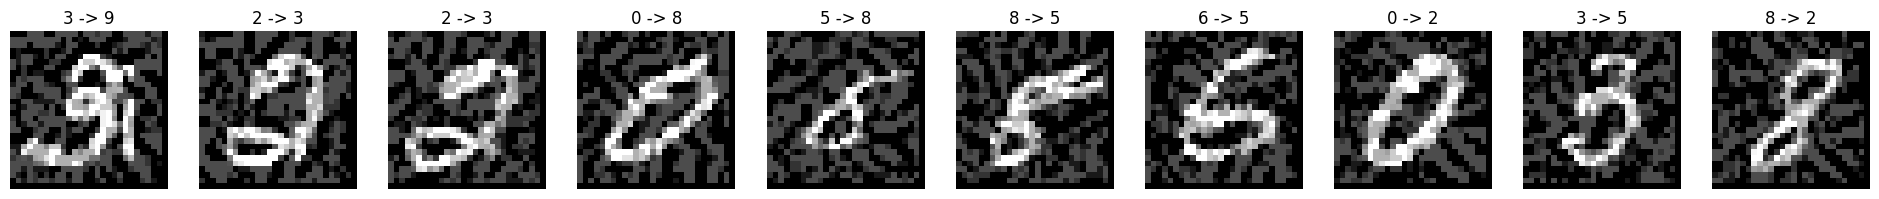

In [15]:
show_images(images[:10].detach().cpu())
show_images_withPred(altered_pgd_images[:10].detach().cpu(),labels[:10].cpu(), outputs[:10].argmax(dim=1).cpu())

# Model Performance Comparatively

When comparing model accuraacy across the three sets of test images, both adversarial attacks clearly heavily impact model performance

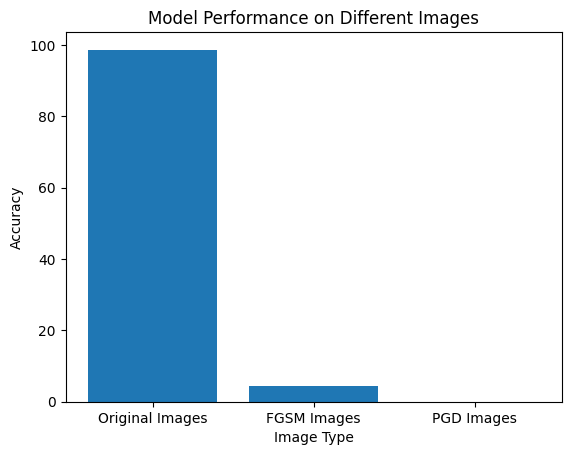

In [16]:
performance = {'Original Images':(correct/total)*100, 'FGSM Images':(correct_fgsm/total_fgsm)*100, 'PGD Images':(correct_pgd/total_pgd)*100}
plt.bar(performance.keys(), performance.values())
plt.xlabel("Image Type")
plt.ylabel("Accuracy")
plt.title("Model Performance on Different Images")
plt.show()

# Visualizing Affect on Feature Maps

Function to obtain feature maps

In [17]:
def getFeatureMaps(ori_images):
  conv_layers = []

  for layer in model.features.children(): #obtaining the model layers
    if isinstance(layer, nn.Conv2d):
      conv_layers.append(layer)

  feature_maps = []
  layer_names = []

  for image in ori_images: #applying each layer to each image for feature map development
    image = image.unsqueeze(0)
    image = image.cuda()
    for layer in conv_layers:
      image = layer(image)
      feature_maps.append(image)
      layer_names.append(str(layer))

  processed_feature_maps = [] #processing each feature map
  for feature_map in feature_maps:
    feature_map = feature_map.squeeze(0)
    mean_feature_map = torch.sum(feature_map,0)/feature_map.shape[0]
    processed_feature_maps.append(mean_feature_map)

  return processed_feature_maps, layer_names #returning the feature map with their layer name


## Original Images

The original feature maps show clearly that the model understood how to interpret the different images

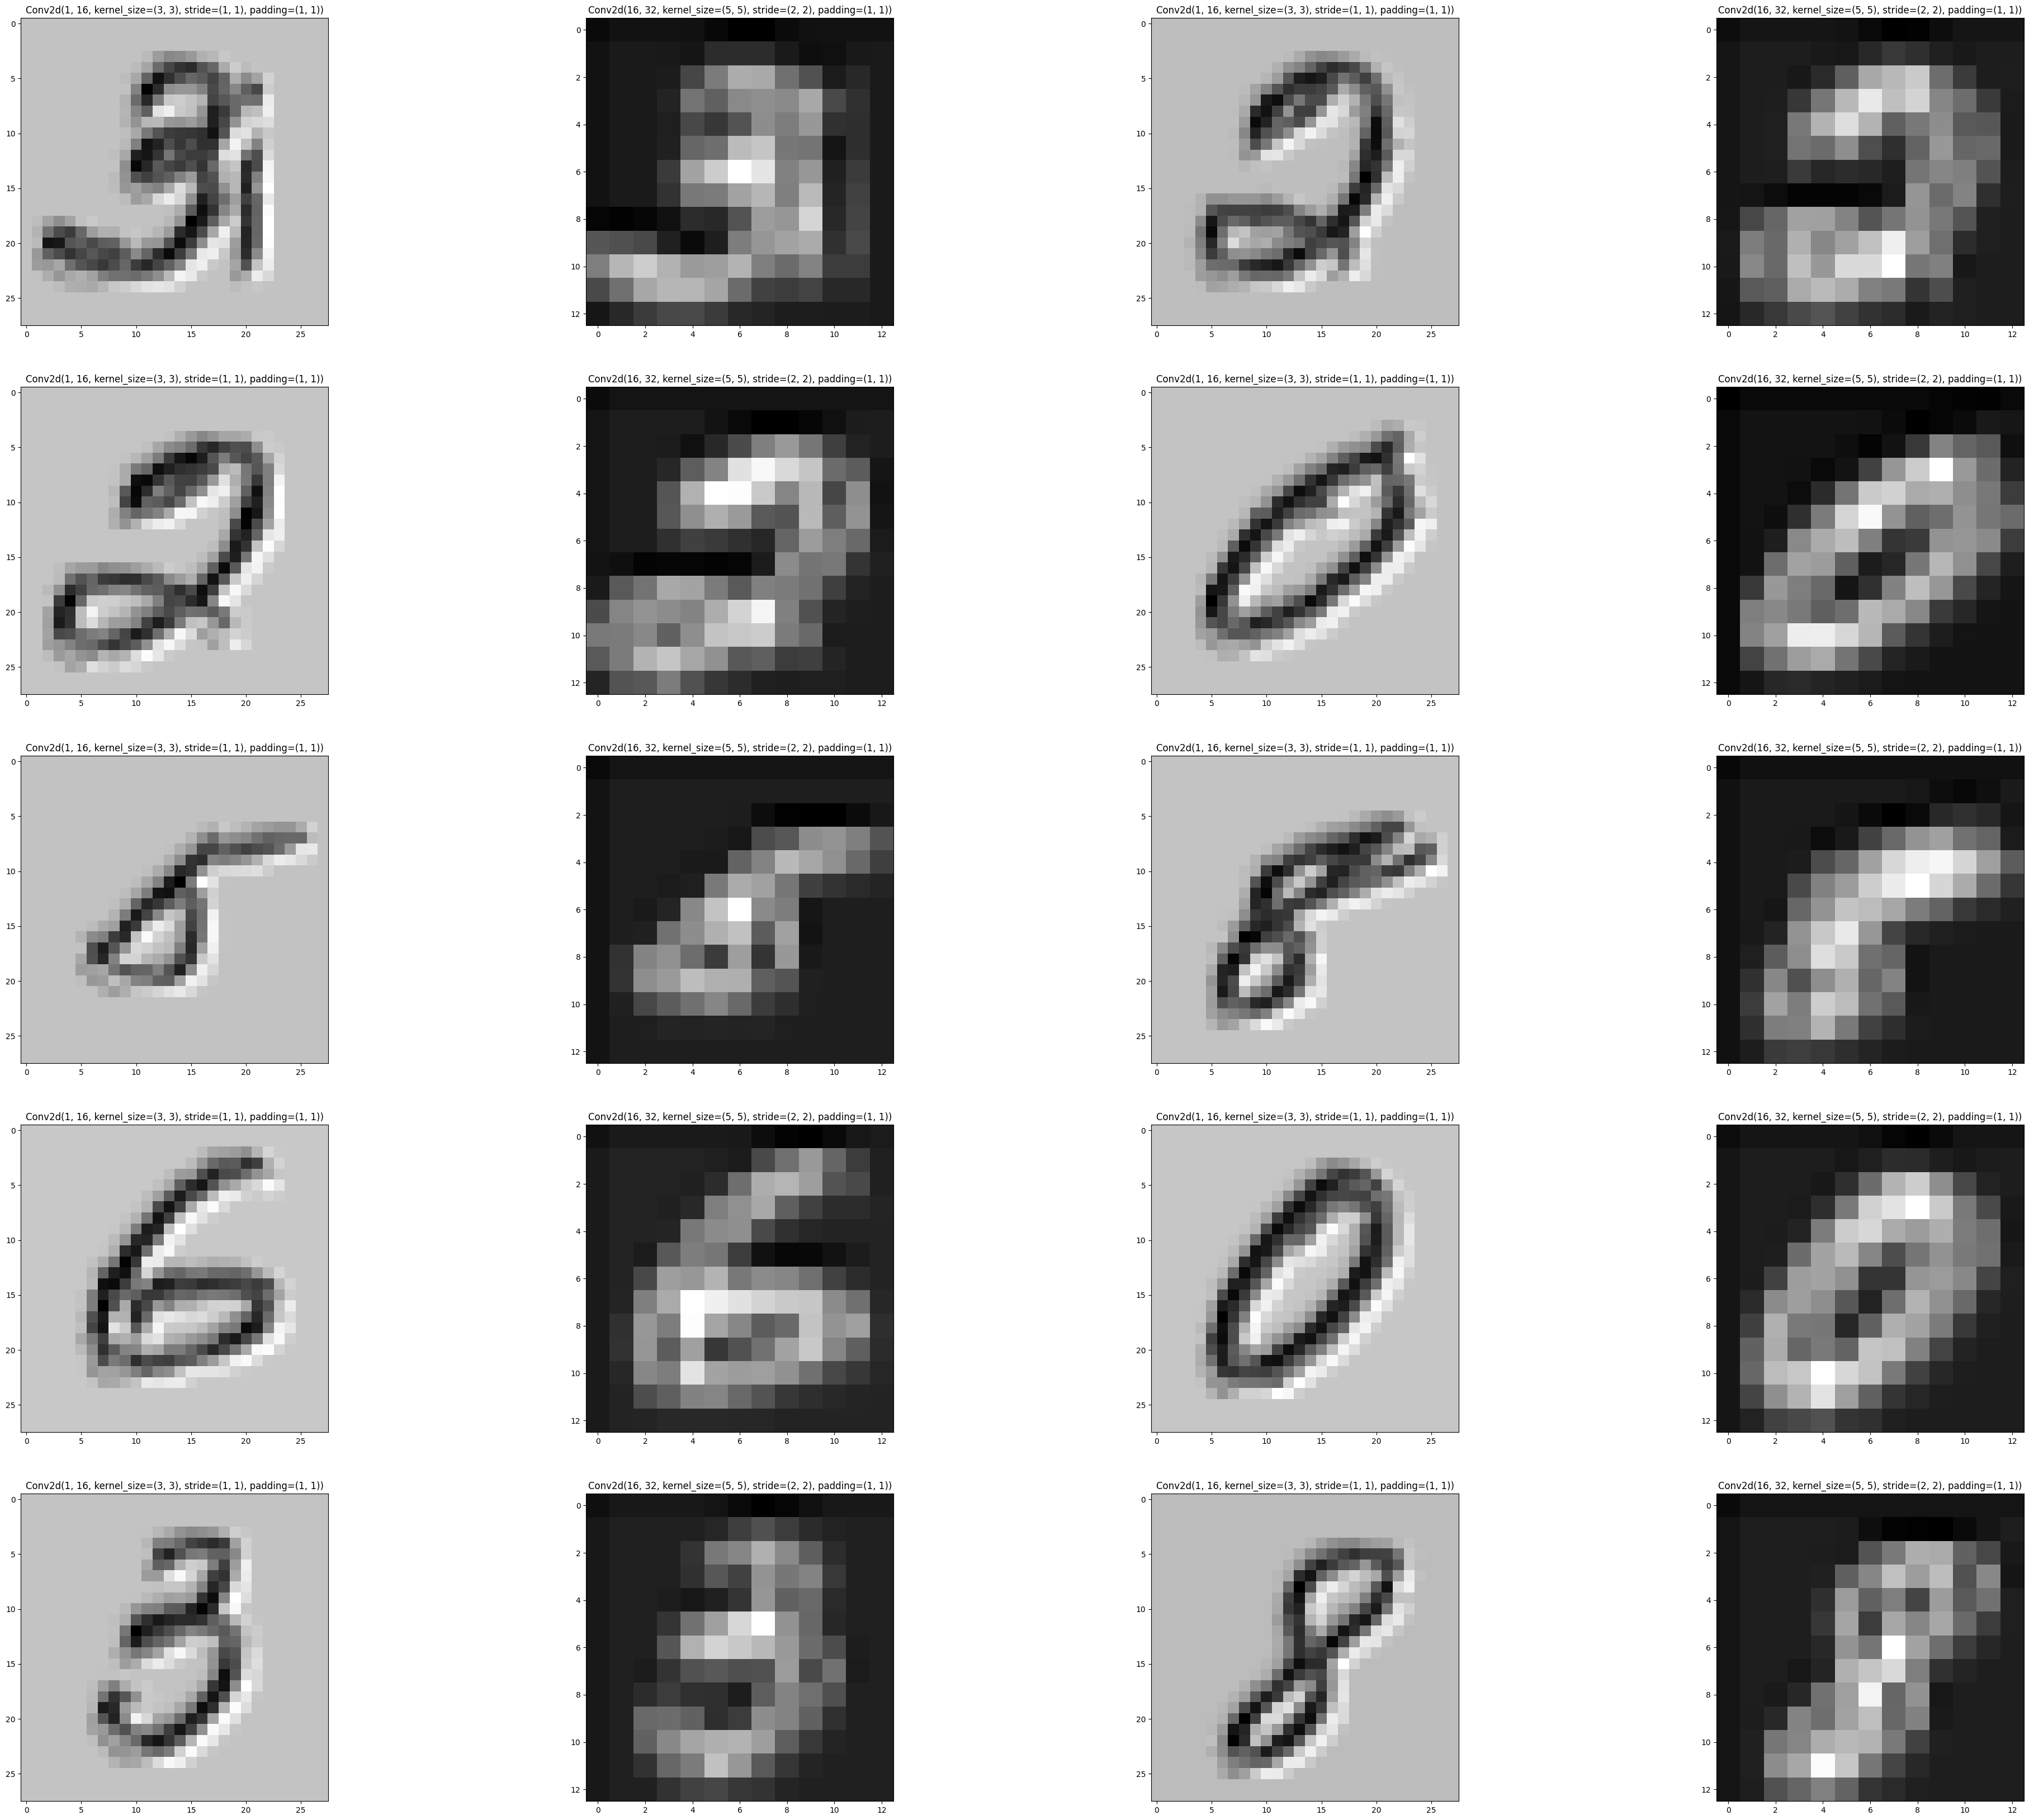

In [18]:
processed_feature_maps, layer_names = getFeatureMaps(images[:10])
fig = plt.figure(figsize=(50, 50))
for i in range(len(processed_feature_maps)):
  ax = fig.add_subplot(6, 4, i+1)
  ax.imshow(processed_feature_maps[i].cpu().detach().numpy(), cmap='gray')
  ax.set_title(layer_names[i])
plt.show()


## FGSM Images

FGSM feature maps show issues that the model was having with the doctored images

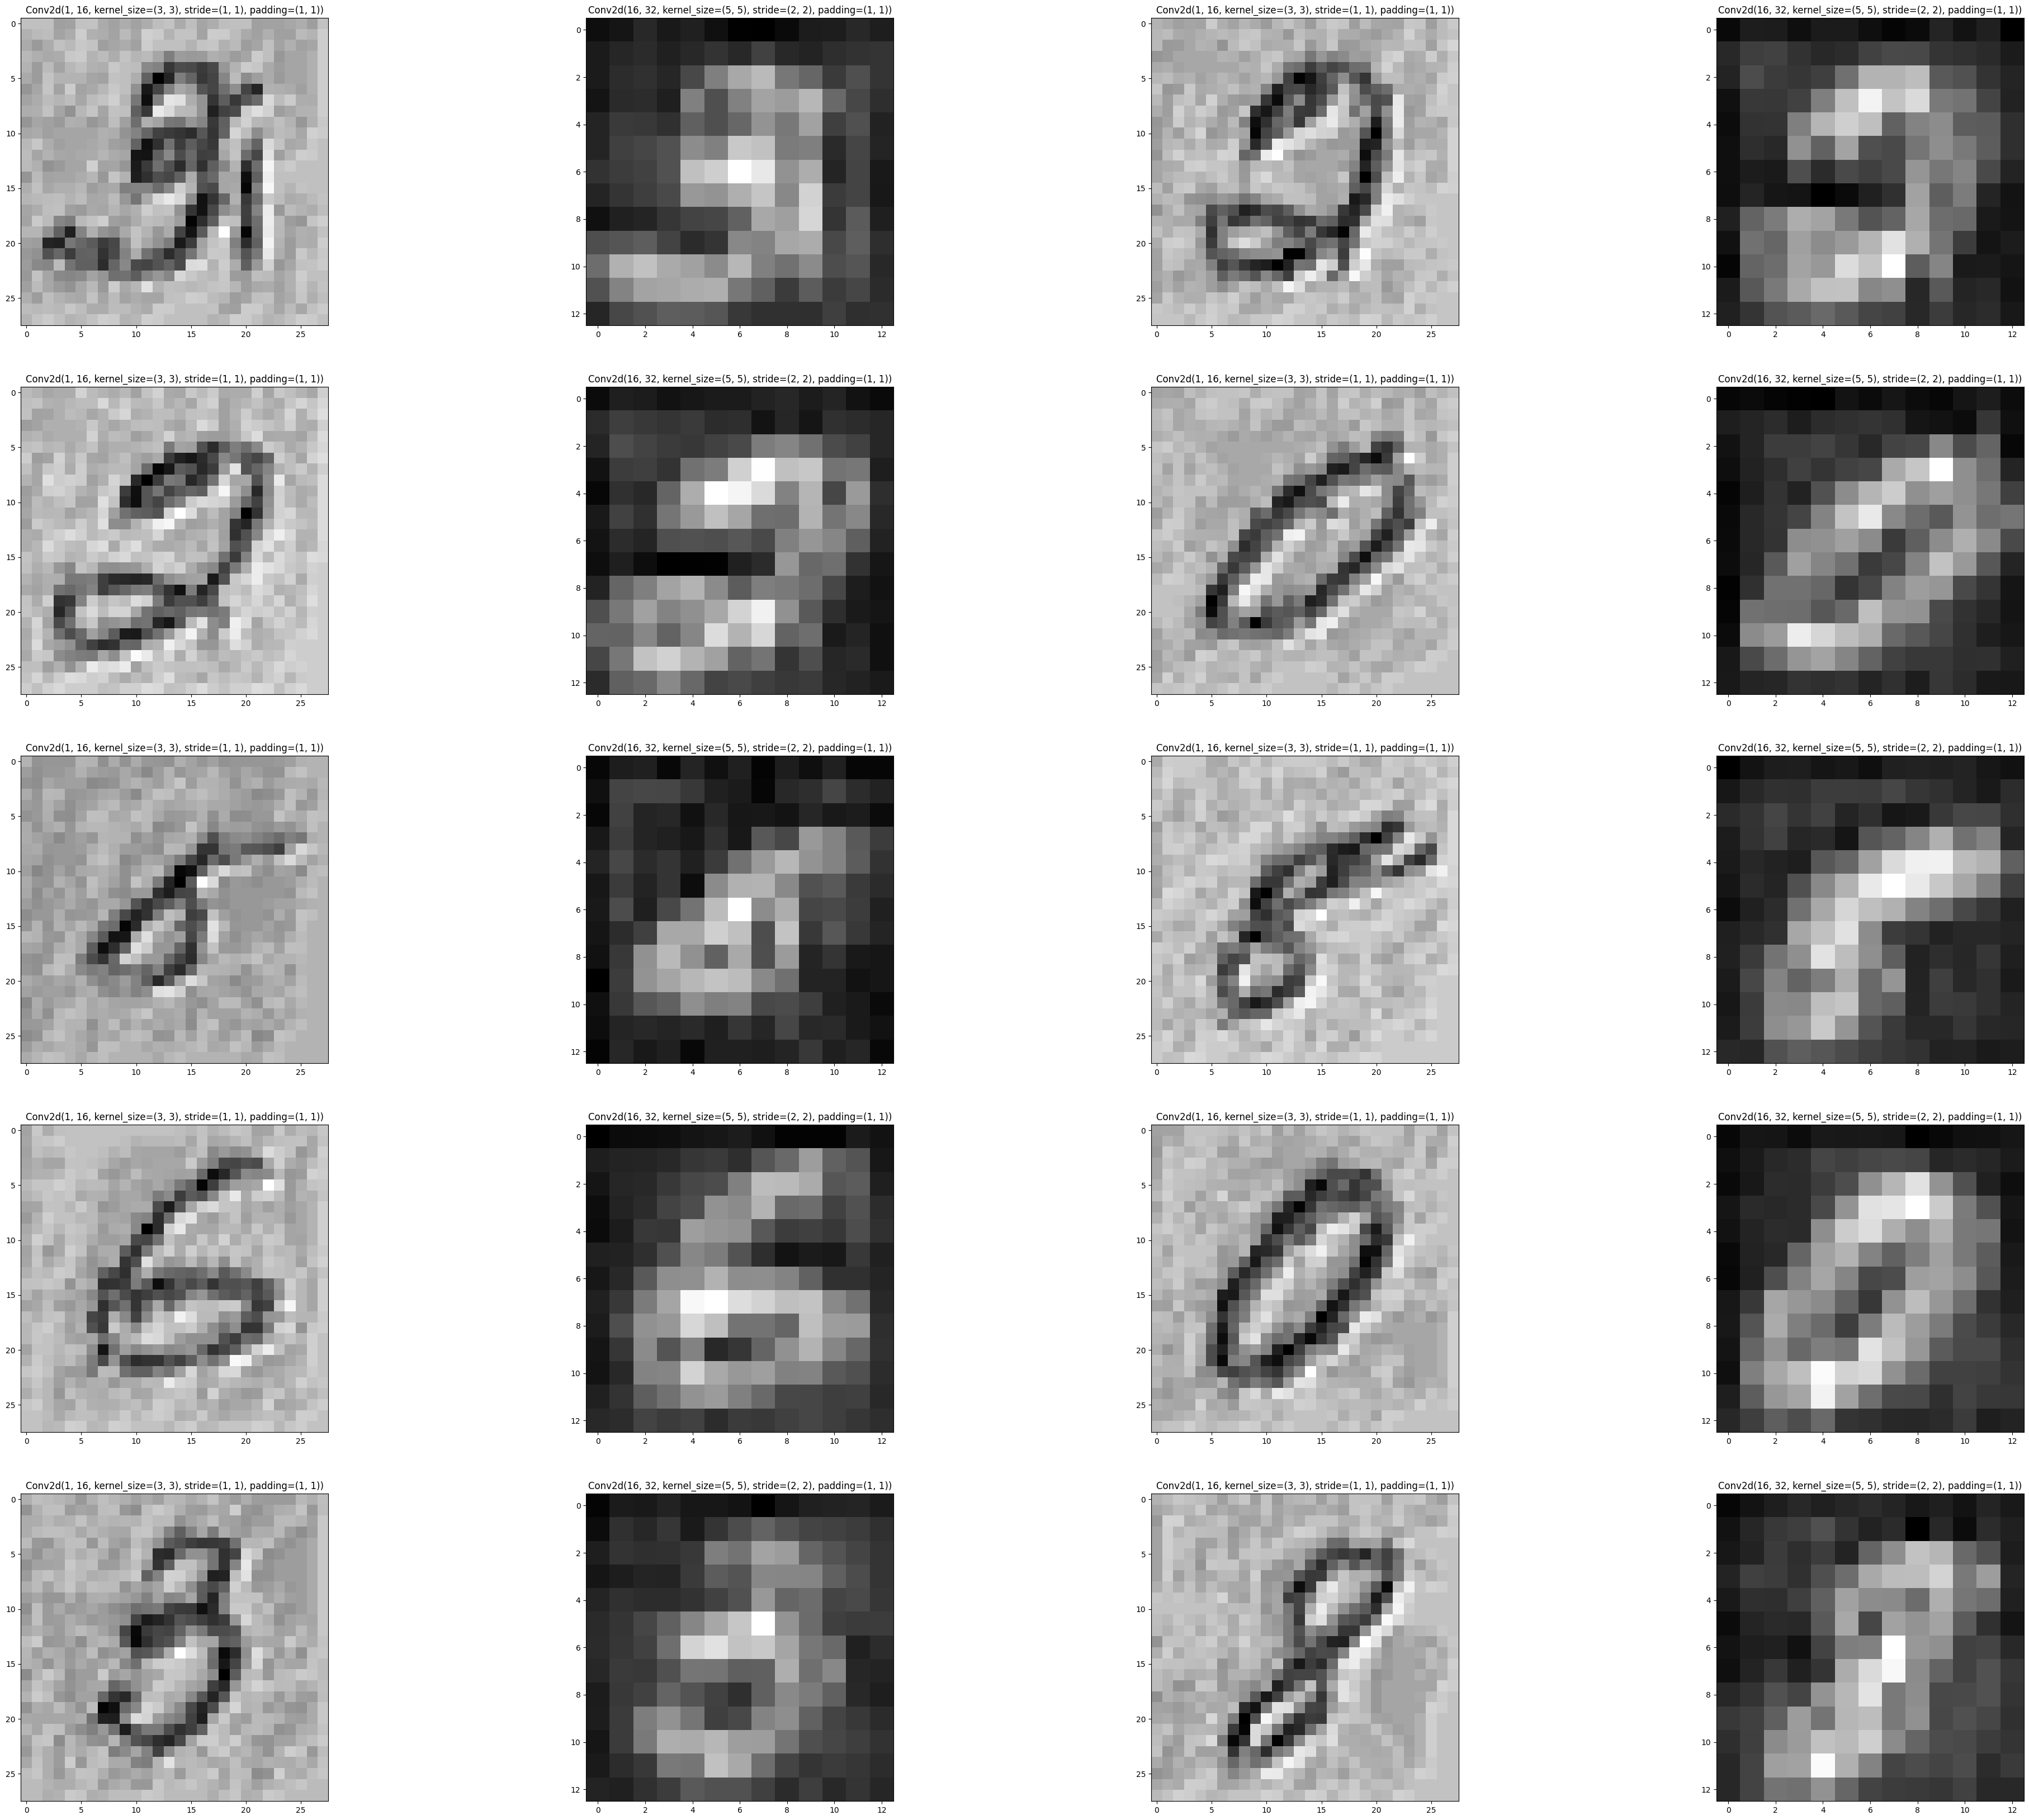

In [19]:
processed_feature_maps, layer_names = getFeatureMaps(altered_fgsm_images[:10])
fig = plt.figure(figsize=(50, 50))
for i in range(len(processed_feature_maps)):
  ax = fig.add_subplot(6, 4, i+1)
  ax.imshow(processed_feature_maps[i].cpu().detach().numpy(), cmap='gray')
  ax.set_title(layer_names[i])
plt.show()

## PGD Images

The PGD show even further exacerbated feature maps, with more contrast shown throughout which clearly confused the model

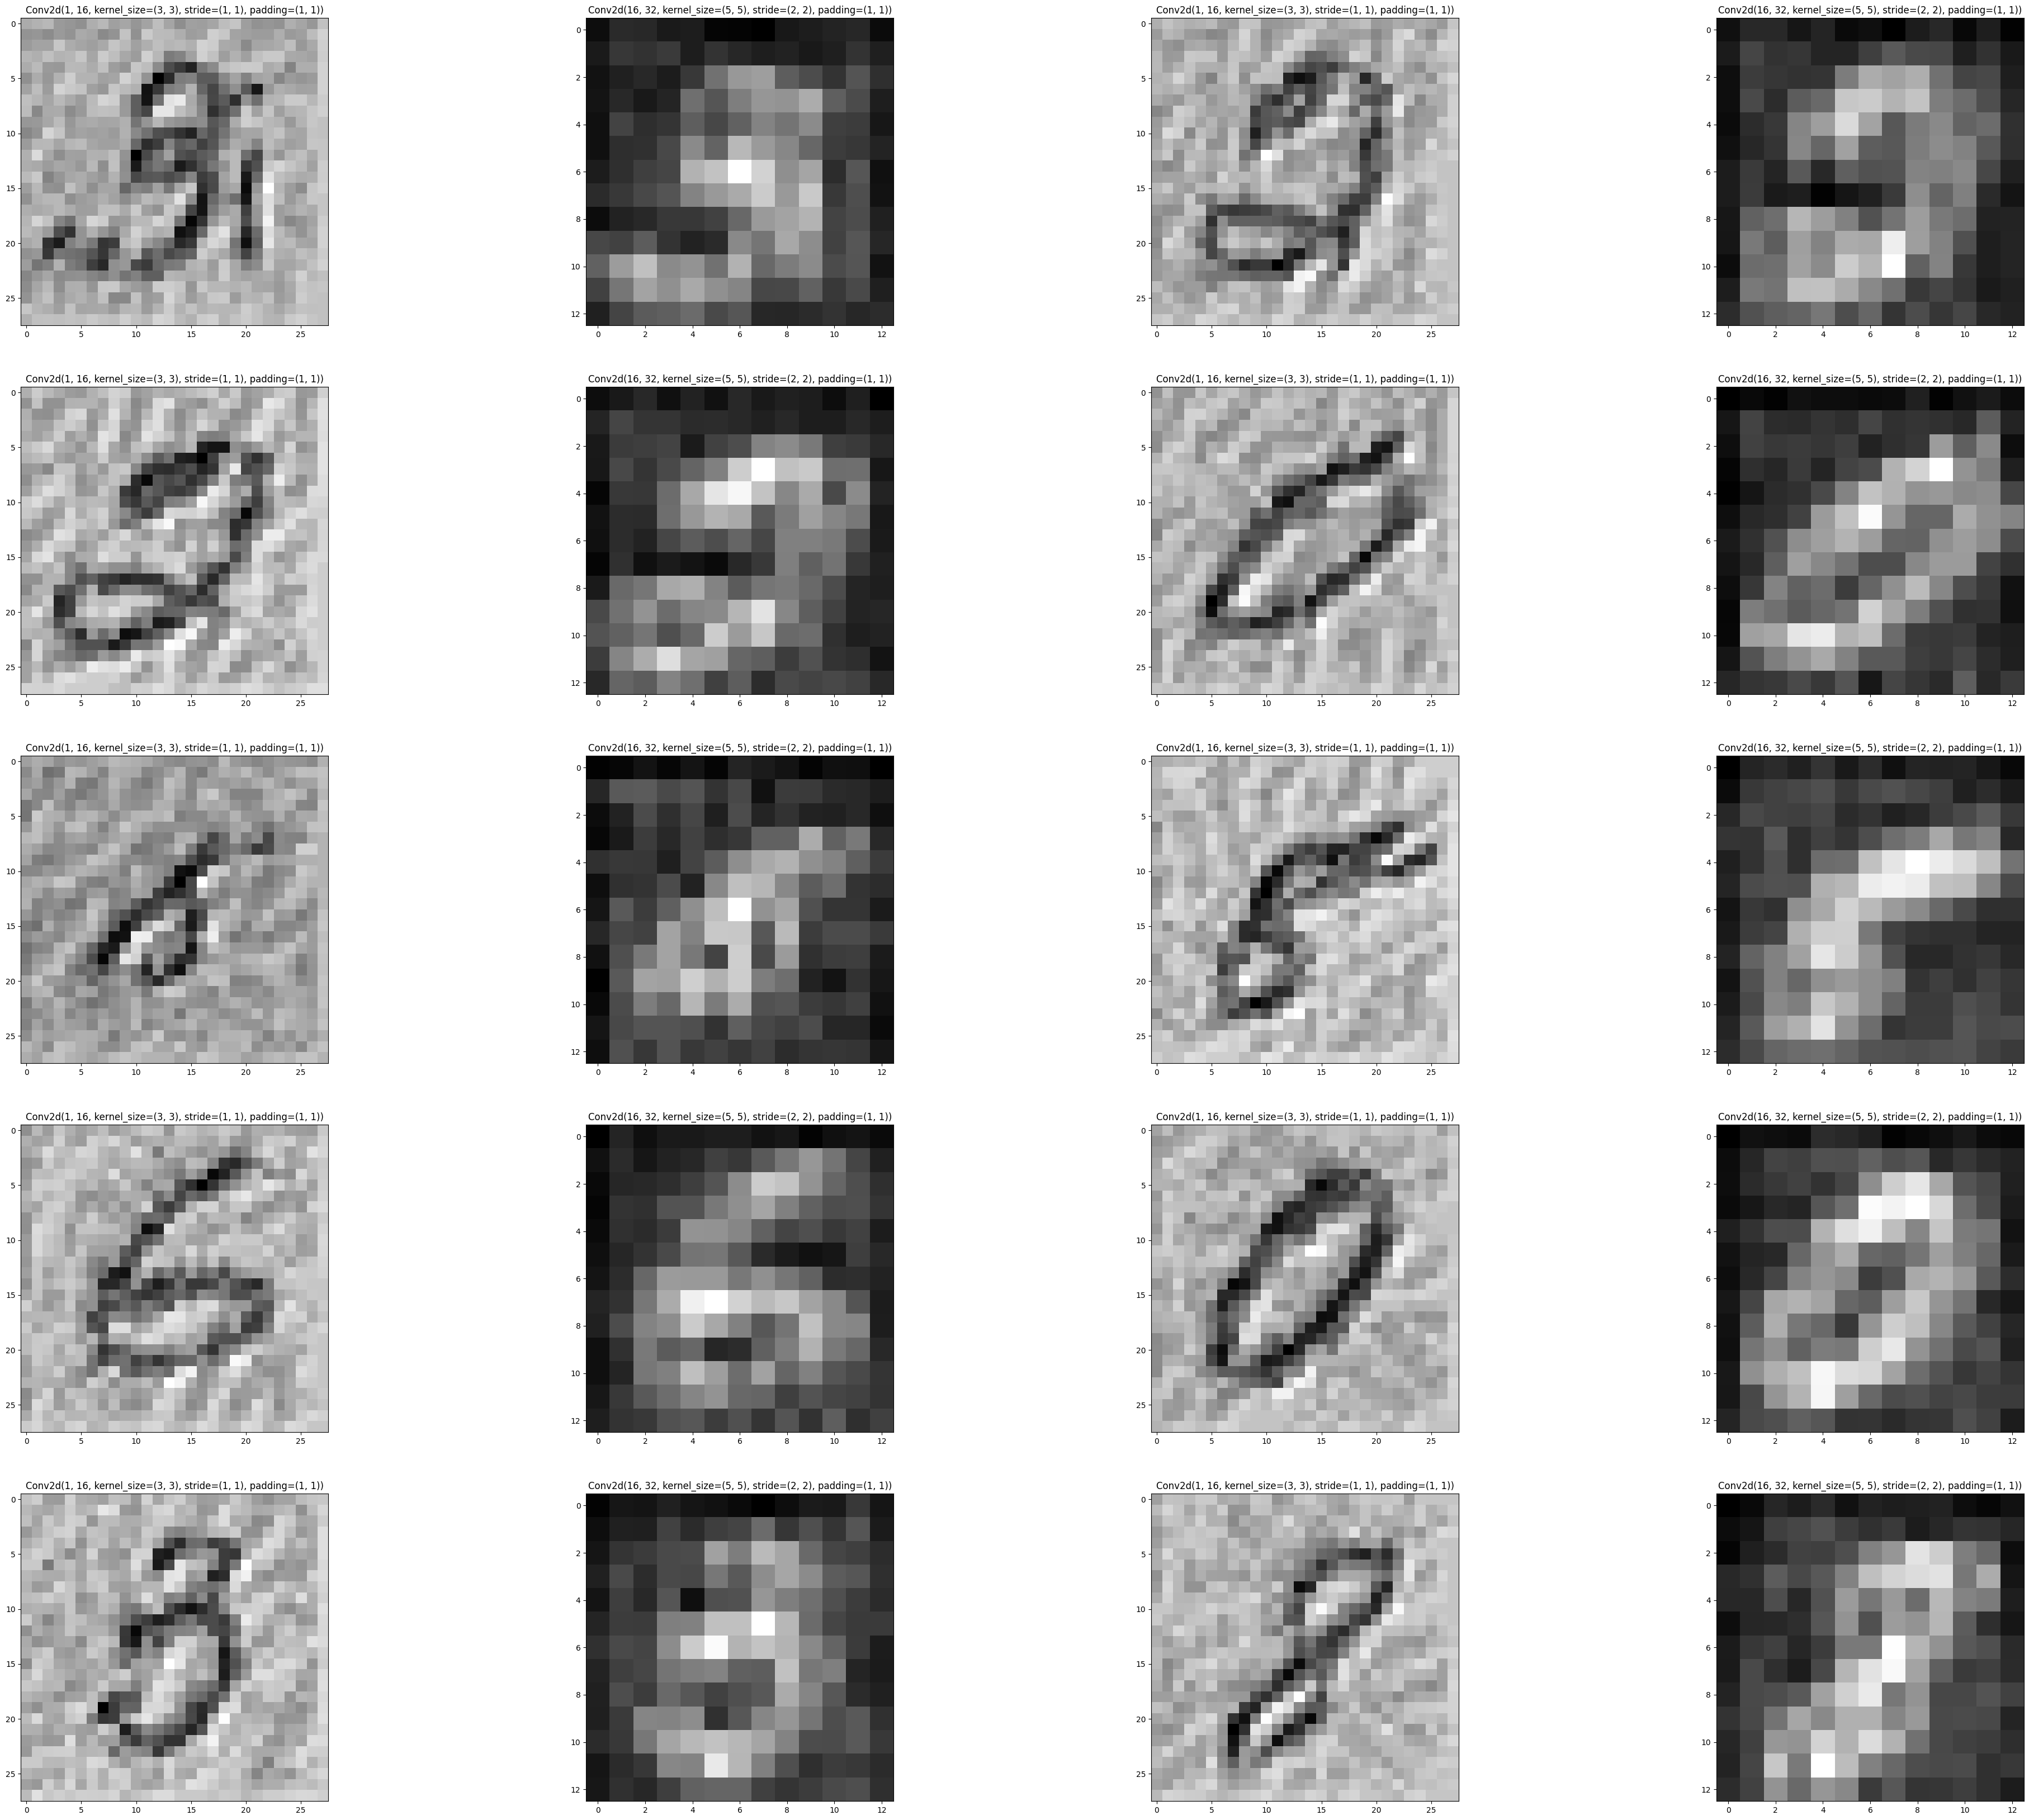

In [20]:
processed_feature_maps, layer_names = getFeatureMaps(altered_pgd_images[:10])
fig = plt.figure(figsize=(50, 50))
for i in range(len(processed_feature_maps)):
  ax = fig.add_subplot(6, 4, i+1)
  ax.imshow(processed_feature_maps[i].cpu().detach().numpy(), cmap='gray')
  ax.set_title(layer_names[i])
plt.show()

# Adversarial Hyperparameter Tuning

## FGSM Tuning

Tuning the FGSM step size parameter to determine ideal step size for FGSM attack

In [21]:
step_sizes = np.linspace(.1, .3, 5) # defining the step sizes
fgsm_images_dict = {}
fgsm_images_accuracy = {}

for step in step_sizes: #Evaluating the model against the 5 step size images
  model.eval()

  correct_fgsm = 0
  total_fgsm = 0

  for images, labels in test_loader:
    images = images.cuda()
    labels = labels.cuda()

    altered_fgsm_images = fgsm(model, criterion, images, labels, step_size=step)

    outputs = model(altered_fgsm_images)

    _, predicted = torch.max(outputs.data, 1)
    total_fgsm += labels.size(0)
    correct_fgsm += (predicted == labels).sum().item()

  fgsm_images_dict[step] = altered_fgsm_images #storing the images
  fgsm_images_accuracy[str(step)] = (correct_fgsm/total_fgsm)*100 #storing the accuracies

In [22]:
print(fgsm_images_accuracy)

{'0.1': 39.11, '0.15': 11.88, '0.2': 4.37, '0.25': 2.0, '0.3': 1.15}


When plotted against one another, the trend clearly shows that the hgiher the step size, the lower the accuracy

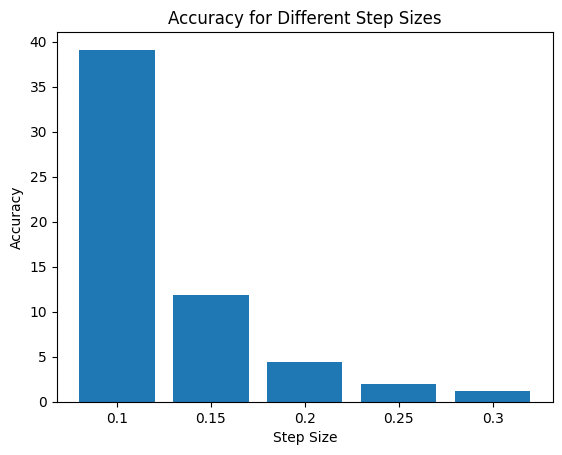

In [24]:
plt.bar(fgsm_images_accuracy.keys(), fgsm_images_accuracy.values())
plt.xlabel('Step Size')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Step Sizes')
plt.show()

Showing the 5 different level of step size images. Clearly after .15, alterations become apparent

0.1


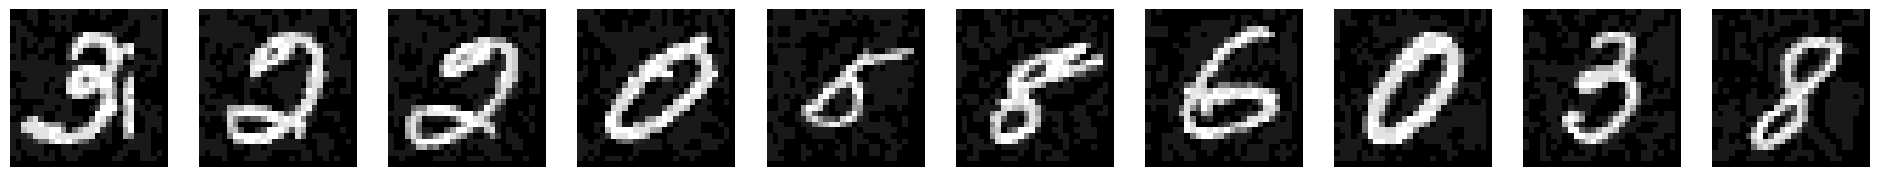

0.15


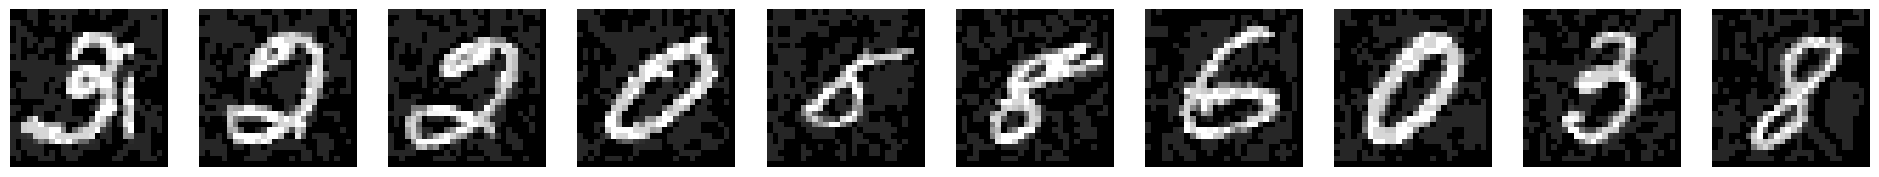

0.2


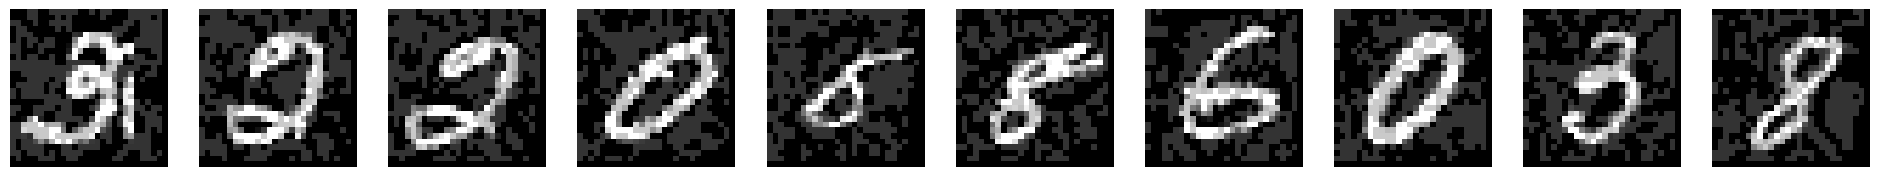

0.25


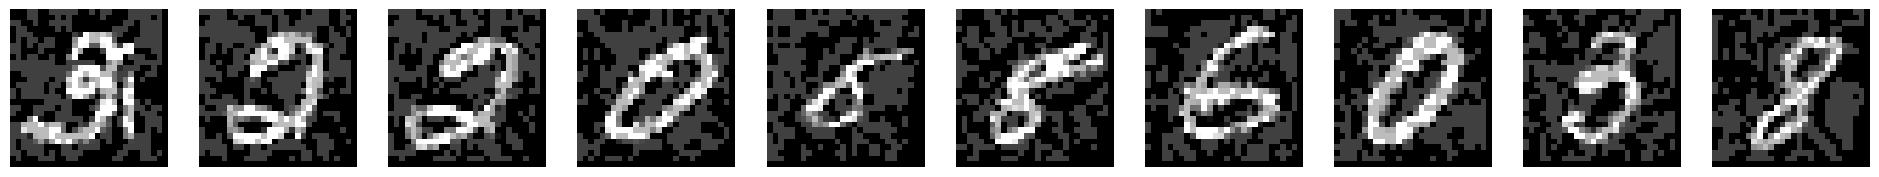

0.3


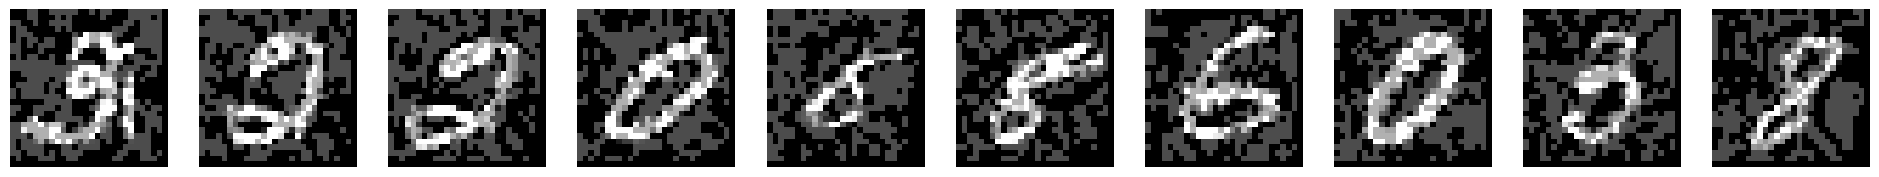

In [25]:
for i in fgsm_images_dict:
  print(i)
  show_images(fgsm_images_dict[i][:10].detach().cpu())

## PGD Tuning

Instead of affecting step size for PGD, altering epsilon for the ideal value

In [26]:
epsilons = np.linspace(.1, .3, 5)
pgd_images_dict = {}
pgd_images_accuracy = {}

for ep in epsilons:
  model.eval()

  correct_pgd = 0
  total_pgd = 0

  for images, labels in test_loader:
    images = images.cuda()
    labels = labels.cuda()

    altered_pgd_images = pgd(model, images, labels, criterion, epsilon=ep, step_size=.1, iters=30)

    outputs = model(altered_pgd_images)

    _, predicted = torch.max(outputs.data, 1)
    total_pgd += labels.size(0)
    correct_pgd += (predicted == labels).sum().item()

  pgd_images_dict[ep] = altered_pgd_images
  pgd_images_accuracy[str(ep)] = (correct_pgd/total_pgd)*100

In [27]:
print(pgd_images_accuracy)

{'0.1': 34.07, '0.15': 1.48, '0.2': 0.0, '0.25': 0.0, '0.3': 0.0}


Here it becomes clear that the higher the epsilon, the worse the model performance

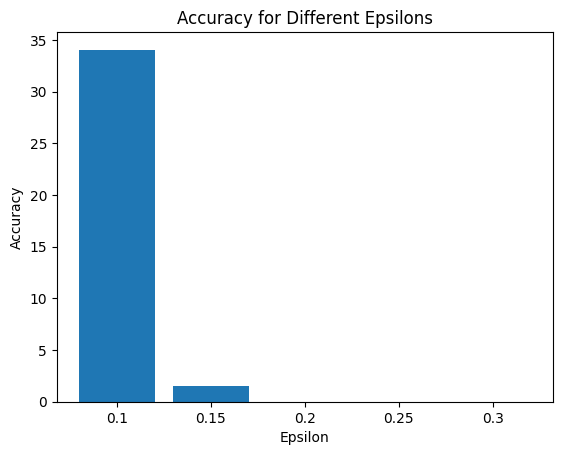

In [29]:
plt.bar(pgd_images_accuracy.keys(), pgd_images_accuracy.values())
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Epsilons')
plt.show()

However, similar to step size in FGSM, the higher the epsilons the more apparent signs of tampering becomes

0.1


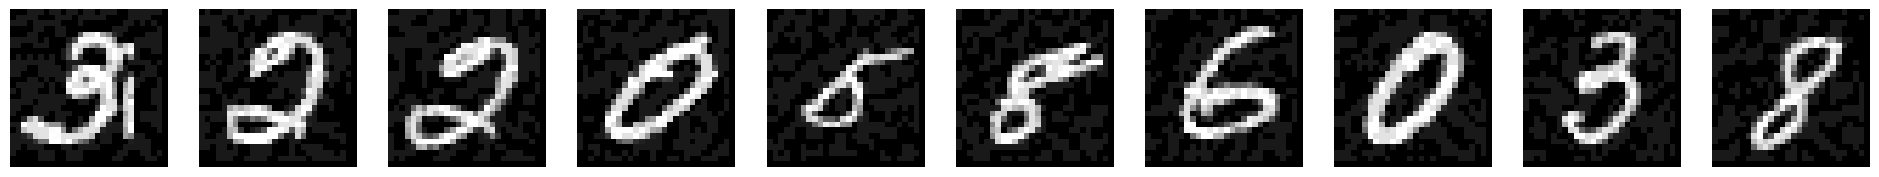

0.15


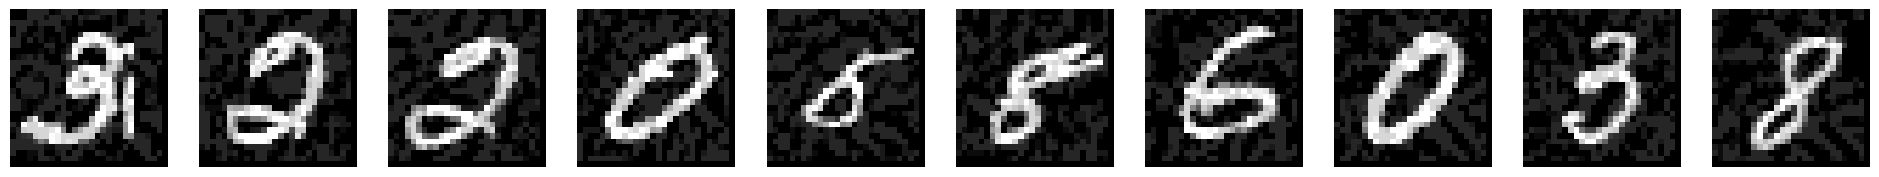

0.2


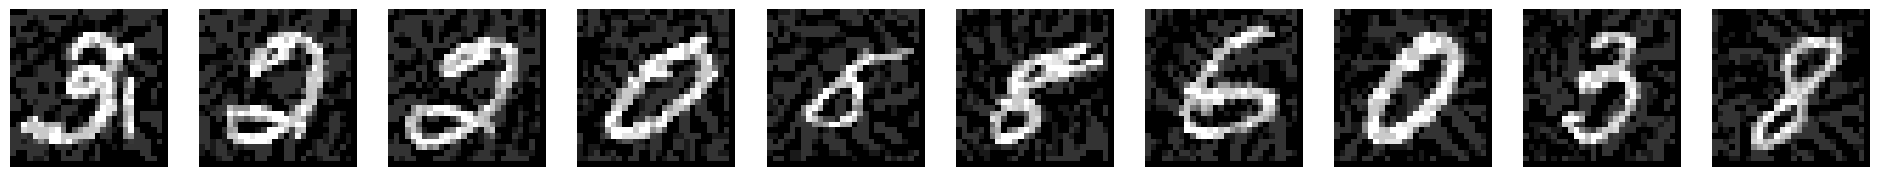

0.25


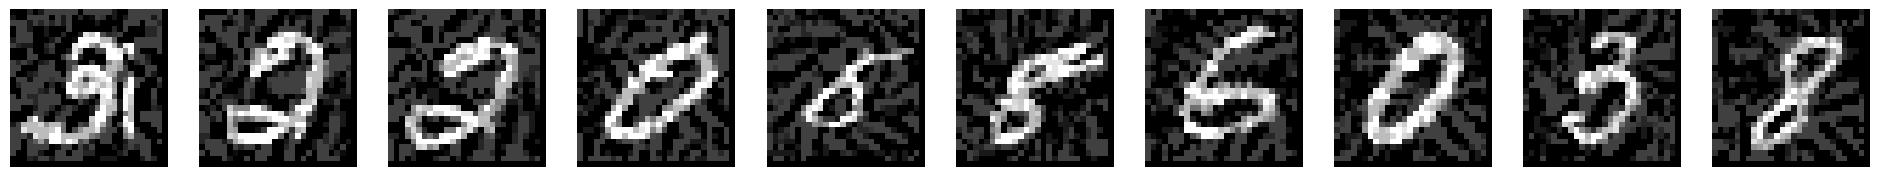

0.3


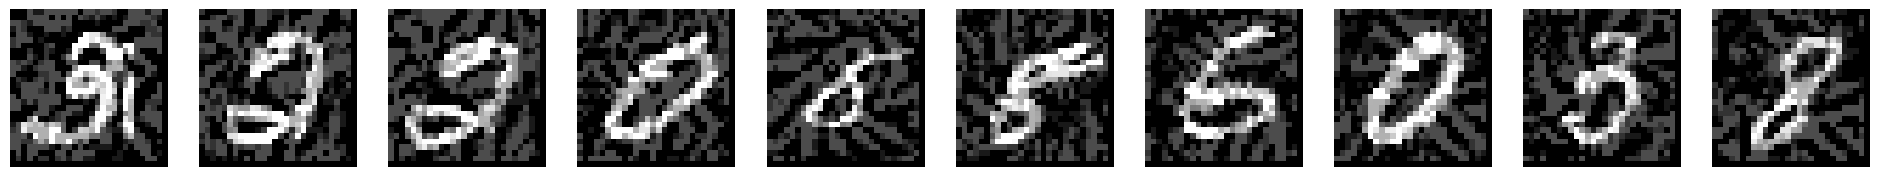

In [30]:
for i in pgd_images_dict:
  print(i)
  show_images(pgd_images_dict[i][:10].detach().cpu())